# LALS demo

LALS scores every visual token of a vision-language model (here Qwen2-VL-7B-Instruct): positive
values lean female, negative values lean male. This notebook runs it on the example images in
`data/examples/`. It needs a GPU and the text database (see the README) and takes a few minutes.

Exact numbers can fluctuate slightly depending on the GPU, library versions and model revision
you use (less than 1% of the LALS range).

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / "utils").is_dir():   # works from the repository root or from notebooks/
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from utils import plots
from utils.functions import LALSScorer, TextDB, image_summary
from utils.models import MODELS, list_images, load_image, load_vlm

EXAMPLES = ROOT / "data" / "examples"
DB_DIR = ROOT / "embeddb" / "qwen2vl"
OUT = ROOT / "outputs"

vlm = load_vlm("qwen2vl")
layers = MODELS["qwen2vl"].sweep_layers   # 4, 8, 12, 16, 20, 24, 27

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


## 1. Kitchen scenes (Figure 3)

The same kitchen with no person, a man, a woman, or both. Token-level LALS at a middle layer (16)
and at the last layer (27).

layer 16: No person +0.012, Man +0.008, Woman +0.117, Man + woman +0.060


layer 27: No person +0.019, Man +0.020, Woman +0.046, Man + woman +0.029


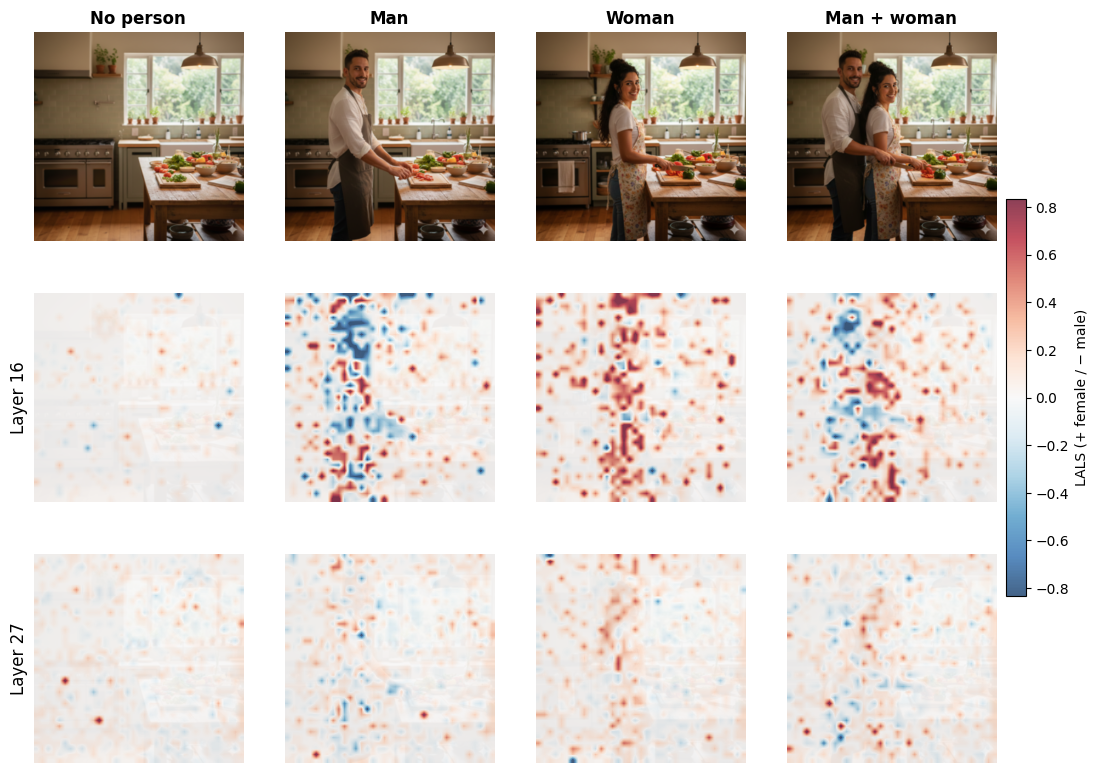

In [2]:
SCENES = {"No person": "noperson_kitchen.png", "Man": "man_kitchen.png",
          "Woman": "woman_kitchen.png", "Man + woman": "people_kitchen.png"}
images = [load_image(EXAMPLES / "kitchen" / name) for name in SCENES.values()]
hidden = [vlm.visual_token_states(image, [16, 27]) for image in images]

maps = []
for layer in [16, 27]:
    scorer = LALSScorer(TextDB.load(DB_DIR, layer), k=20)
    maps.append([scorer.token_map(scorer.neighbours(h[layer]), vlm.visual_grid(image))
                 for h, image in zip(hidden, images)])
    scores = [image_summary(scorer.token_scores(h[layer]))["mean"] for h in hidden]
    print(f"layer {layer}: " + ", ".join(f"{name} {s:+.3f}" for name, s in zip(SCENES, scores)))

plots.token_heatmaps(images, maps, list(SCENES), ["Layer 16", "Layer 27"])
plt.show()

## 2. LALS across layers

Two example images per occupation, scored at seven layers.

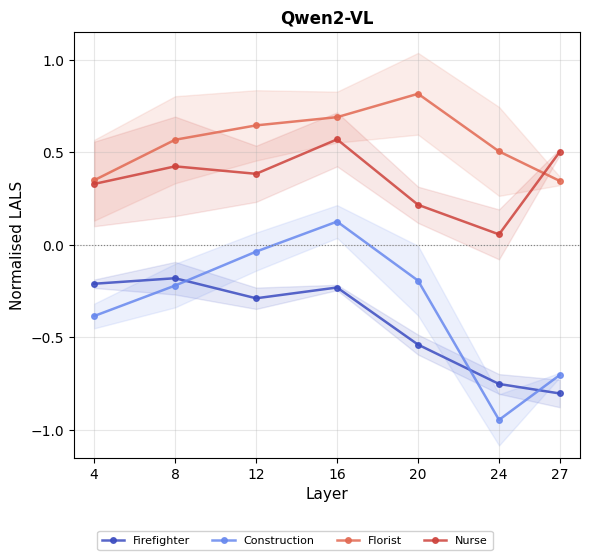

In [3]:
occupations = sorted(p.name for p in (EXAMPLES / "ambiguous").iterdir())
sweep = {occ: {} for occ in occupations}
for layer in layers:
    scorer = LALSScorer(TextDB.load(DB_DIR, layer), k=20)
    for occ in occupations:
        sweep[occ][str(layer)] = [
            {**image_summary(scorer.token_scores(vlm.visual_token_states(load_image(p), [layer])[layer])),
             "filename": p.name}
            for p in list_images(EXAMPLES / "ambiguous" / occ)]

(OUT / "layer_sweep").mkdir(parents=True, exist_ok=True)
(OUT / "layer_sweep" / "qwen2vl.json").write_text(json.dumps({"occupations": sweep}))
plots.layer_sweep_figure(OUT, models=["qwen2vl"])
plt.show()

## 3. The paper's results

The same plot for the four models, 15 occupations and 25 images each, from the scores in
`data/processed/`.

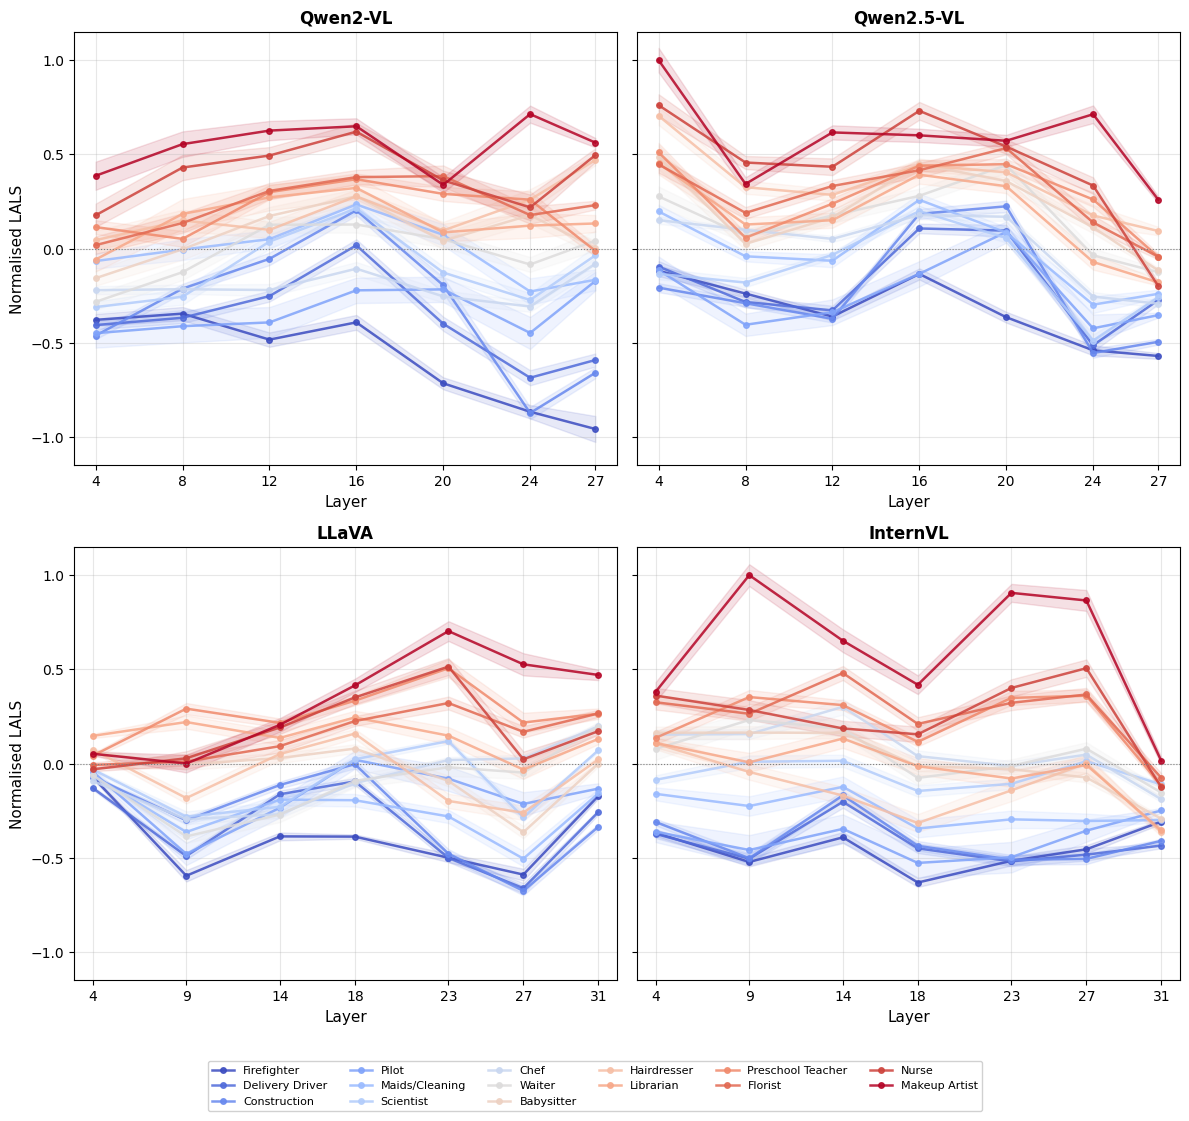

In [4]:
plots.layer_sweep_figure(ROOT / "data" / "processed")
plt.show()